In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Cargo el dataset

In [6]:
df = pd.read_csv('../data/raw/hospitalizaciones_train.csv')

# Información General

In [79]:
df.shape

(410000, 15)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410000 entries, 0 to 409999
Data columns (total 15 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Available Extra Rooms in Hospital  410000 non-null  int64  
 1   Department                         410000 non-null  object 
 2   Ward_Facility_Code                 410000 non-null  object 
 3   doctor_name                        410000 non-null  object 
 4   staff_available                    410000 non-null  int64  
 5   patientid                          410000 non-null  int64  
 6   Age                                410000 non-null  object 
 7   gender                             410000 non-null  object 
 8   Type of Admission                  410000 non-null  object 
 9   Severity of Illness                410000 non-null  object 
 10  health_conditions                  272798 non-null  object 
 11  Visitors with Patient              4100

## Tipos de datos presentes

In [12]:
df.dtypes

Available Extra Rooms in Hospital      int64
Department                            object
Ward_Facility_Code                    object
doctor_name                           object
staff_available                        int64
patientid                              int64
Age                                   object
gender                                object
Type of Admission                     object
Severity of Illness                   object
health_conditions                     object
Visitors with Patient                  int64
Insurance                             object
Admission_Deposit                    float64
Stay (in days)                         int64
dtype: object

## Cantidad de variables de cada tipo de dato

In [17]:
(df
 .dtypes
 .value_counts())

object     9
int64      5
float64    1
Name: count, dtype: int64

In [80]:
df.describe()

,Available Extra Rooms in Hospital,staff_available,patientid,Visitors with Patient,Admission_Deposit,Stay (in days)
count,410000.000000,410000.000000,410000.000000,410000.000000,410000.000000,410000.000000
mean,3.639376,5.020946,63095.940020,3.552520,4723.419239,12.378193
std,2.701702,3.158018,41686.175937,2.247459,1047.420292,7.905618
min,0.000000,0.000000,-3146.000000,0.000000,1654.005148,3.000000
25%,2.000000,2.000000,25405.000000,2.000000,4072.638351,8.000000
50%,3.000000,5.000000,57736.000000,3.000000,4627.488745,9.000000
75%,4.000000,8.000000,103278.250000,4.000000,5092.349430,11.000000
max,24.000000,10.000000,134400.000000,32.000000,10104.726390,51.000000


## Ejemplos de registros existentes

In [18]:
df.head(3)

,Available Extra Rooms in Hospital,Department,Ward_Facility_Code,doctor_name,staff_available,patientid,Age,gender,Type of Admission,Severity of Illness,health_conditions,Visitors with Patient,Insurance,Admission_Deposit,Stay (in days)
0,4,gynecology,D,Dr Sophia,0,33070,41-50,Female,Trauma,Extreme,Diabetes,4,Yes,2966.408696,8
1,4,gynecology,B,Dr Sophia,2,34808,31-40,Female,Trauma,Minor,Heart disease,2,No,3554.835677,9
2,2,gynecology,B,Dr Sophia,8,44577,21-30,Female,Trauma,Extreme,Diabetes,2,Yes,5624.733654,7


# Relacion entre variables

# Correlacion con el Target

# Outliers

# Valores Faltantes

In [28]:
(df
 .isna()
 .any()
)

Available Extra Rooms in Hospital    False
Department                           False
Ward_Facility_Code                   False
doctor_name                          False
staff_available                      False
patientid                            False
Age                                  False
gender                               False
Type of Admission                    False
Severity of Illness                  False
health_conditions                     True
Visitors with Patient                False
Insurance                            False
Admission_Deposit                    False
Stay (in days)                       False
dtype: bool

In [29]:
(df
 .isna()
 .sum()
)

Available Extra Rooms in Hospital         0
Department                                0
Ward_Facility_Code                        0
doctor_name                               0
staff_available                           0
patientid                                 0
Age                                       0
gender                                    0
Type of Admission                         0
Severity of Illness                       0
health_conditions                    137202
Visitors with Patient                     0
Insurance                                 0
Admission_Deposit                         0
Stay (in days)                            0
dtype: int64

## Proporcion de Valores Faltantes

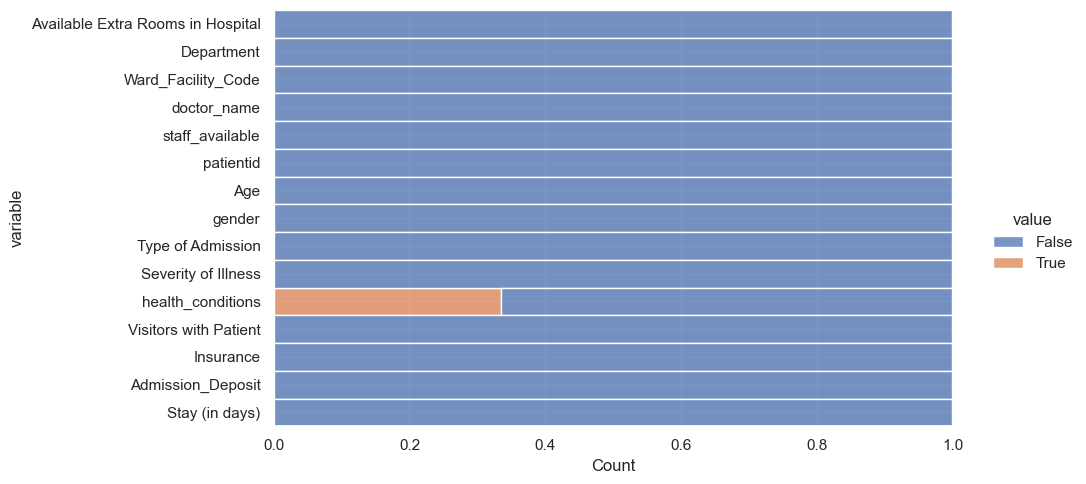

In [34]:
(df
 .isnull()
 .melt()
 .pipe(
    lambda df:(
        sns.displot(
            data=df,
            y='variable',
            hue='value',
            multiple='fill',
            aspect=2
        )
    )
    )
)

## Grafico de los valores faltantes en todo el conjunto de datos

<Axes: >

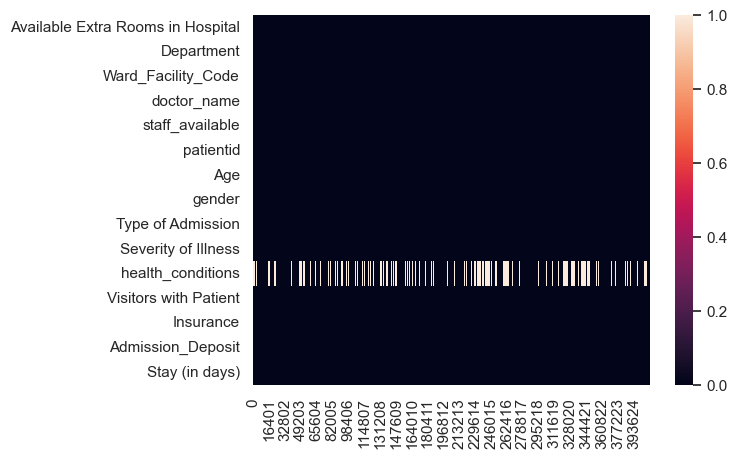

In [36]:
(df
 .isnull()
 .transpose()
 .pipe(
    lambda df:(
        sns.heatmap(
            data=df
            )
        )
    )
)

## ¿Cúantas observaciones se pierden si elinimo los datos?

In [45]:
porcentaje_elim = (df['health_conditions'].isna().mean())*100
print(f'El porcentaje de filas eliminadas es de {porcentaje_elim:.2f}%')

El porcentaje de filas eliminadas es de 33.46%


## Porcentaje de cada valor de la columna "health_conditions"

In [58]:
(
    df['health_conditions']
    .value_counts(dropna=False, normalize=True)*100
    
)

health_conditions
NaN                    33.463902
Other                  19.106098
High Blood Pressure    15.631463
Diabetes               14.314390
Asthama                12.299512
Heart disease           5.184634
Name: proportion, dtype: float64

## Relacion entre valores faltanes en "health_conditions" y "Severity of Illness"

In [51]:
df.groupby(df['health_conditions'].isna())['Severity of Illness'].value_counts(normalize=True)*100

health_conditions  Severity of Illness
False              Moderate               53.744529
                   Minor                  26.301146
                   Extreme                19.954325
True               Moderate               61.373012
                   Minor                  26.346555
                   Extreme                12.280433
Name: proportion, dtype: float64

## Promedio de "Stay (in days)" según valores faltantes en "health_conditions"

In [77]:
df.groupby(df['health_conditions'].isna())['Stay (in days)'].mean()

health_conditions
False    12.384490
True     12.365673
Name: Stay (in days), dtype: float64

## Promedio de "Stay (in days)" según valores faltantes en "health_conditions" por valores

In [73]:
df.groupby('health_conditions')['Stay (in days)'].mean()

health_conditions
Asthama                12.373661
Diabetes               12.357767
Heart disease          12.311615
High Blood Pressure    12.395637
Other                  12.422136
Name: Stay (in days), dtype: float64

## Otros

In [21]:
for col in ['Department', 'Ward_Facility_Code','Age',
       'Type of Admission', 'Severity of Illness', 'health_conditions']:
    val = {col : df[col].sort_values().unique()}
    print(val)

{'Department': array(['TB & Chest disease', 'anesthesia', 'gynecology', 'radiotherapy',
       'surgery'], dtype=object)}
{'Ward_Facility_Code': array(['A', 'B', 'C', 'D', 'E', 'F'], dtype=object)}
{'Age': array(['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70',
       '71-80', '81-90', '91-100'], dtype=object)}
{'Type of Admission': array(['Emergency', 'Trauma', 'Urgent'], dtype=object)}
{'Severity of Illness': array(['Extreme', 'Minor', 'Moderate'], dtype=object)}
{'health_conditions': array(['Asthama', 'Diabetes', 'Heart disease', 'High Blood Pressure',
       'Other', nan], dtype=object)}


In [78]:
df.duplicated().sum()

np.int64(0)

# Informe final

### Primera observación

- El dataset tiene 15 columnas y 410000 filas
- Cada fila corresponde a los datos de un paciente
- No hay datos faltantes (al sacar los valores únicos de cada columna no presentaron valores faltantes)
- No hay filas duplicadas

 **Descripción de las dimensiones**
- Available Extra Rooms in Hospital: Habitaciones adicionales disponibles en el hospital. Una habitación no es igual a un paciente, pueden ser individuales o compartidas.
- Department: Área de atención a la que ingresa el paciente. 
- Ward_Facility_Code: Código de la habitación del paciente.
- doctor_name: Nombre de el/la doctor/a a cargo del paciente.
- staff_available: Cantidad de personal disponible al momento del ingreso del paciente.
- patientid: Identificador del paciente.
- Age: Edad del paciente.
- gender: Género del paciente.
- Type of Admission: Tipo de ingreso registrado según la situación de ingreso del paciente.
- Severity of Illness: Gravedad de la enfermedad/condición/estado del paciente al momento del ingreso.
- health_conditions: Condiciones de salud del paciente. 
- Visitors with Patient: Cantidad de visitantes registrados para el paciente.
- Insurance: Indica si la persona posee o no seguro de salud. 
- Admission_Deposit: Pago realizado a nombre del paciente, con el fin de cubrir los costos iniciales de internación. 
- Stay (in days): Días registrados de estancia hospitalaria.

### ¿Qué tipo de datos tengo?

* Cuantitativos 
    - Discretos: Available Extra Rooms in Hospital, staff_available, Age, Visitors with Patient, Stay (in days)
    - Continuos: Admission_Deposit
* Cualitativos
    - Nominales: Department, Ward_Facility_Code, doctor_name, gender, Type of Admission, health_conditions
    - Ordinales: Severity of Illness,
    - Binario: Insurance